# Implementing Logistic Regression using Scikit-Learn

The sinking of the Titanic is one of the most infamous shipwrecks in history. On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone onboard, resulting in the death of 1502 out of 2224 passengers and crew. While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others. We will be working with the [Titanic Data Set from Kaggle](https://www.kaggle.com/c/titanic). We'll be trying to predict a classification: survival or deceased.

 - **Variable Name -  Variable Description**
 - PassengerID - Passenger ID          
 - Survived - Survival (0 = No; 1 = Yes)
 - Pclass - Passenger Class (1 = 1st; 2 = 2nd; 3 = 3rd)
 - Name	- Name
 - Sex - Sex
 - Age - Age in years
 - SibSp - Number of Siblings/Spouses Aboard
 - Parch - Number of Parents/Children Aboard
 - Ticket - Ticket Number 
 - Fare - Passenger Fare
 - Cabin - Cabin number
 - Embarked - Port of Embarkation (C = Cherbourg; Q = Queenstown; S = Southampton)
 
 ### Name: Mandar Sanju Bavdane

### a. Import Libraries

Import all necessary libraries


In [243]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import roc_curve, auc,precision_recall_curve

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

import numpy as np

Our target variable will be **survived**.  Use the rest of the fields mentioned above to predict whether a passenger survived the Titanic shipwreck.

### b.	Data Loading / Preprocessing
#### i.	Loading
1. Load the data <df_train.csv> and <df_test.csv> as a pandas dataframe using the `pandas.read_csv` function. The ‘df_test.csv’ has been preprocessed (i.e., null values have been dropped, certain columns etc. have been dropped) and should not be changed apart from splitting the dataframe into X_test and y_test.  The ‘df_train’ data has NOT been preprocessed and you will need to preprocess and prepare the ‘df_train’ dataframe. Note: Neither df_train nor df_test have been scaled. The next few steps will enumerate data preprocessing, scaling requirements we need to perform.

In [244]:
df_train = pd.read_csv('df_train.csv')
df_test = pd.read_csv('df_test.csv')

2. The resulting dataframe (i.e., df_train) should have the shape (712,12) indicating that there are 712 instances and 12 columns.

In [245]:
print(df_train.shape)
print(df_test.shape)

(712, 12)
(179, 9)


3. In df_train dataframe, currently you have 12 columns which are the following – PassengerID, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, Embarked and the Survived column (target variable).

In [246]:
print(df_train.columns.tolist())
df_train.head()

['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Survived']


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,299,1,"Saalfeld, Mr. Adolphe",male,NaN,0,0,19988,30.5000,C106,S,1
1,9,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,1
2,414,2,"Cunningham, Mr. Alfred Fleming",male,NaN,0,0,239853,0.0000,NaN,S,0
3,542,3,"Andersson, Miss. Ingeborg Constanzia",female,9.0,4,2,347082,31.2750,NaN,S,0
4,557,1,"Duff Gordon, Lady. (Lucille Christiana Sutherl...",female,48.0,1,0,11755,39.6000,A16,C,1


4. Use the `pandas.isnull().sum()` function to check if there are any missing values in the df_train dataframe. Report which columns have missing (i.e., null) values and provide the number of the null values in the columns.

In [247]:
print(df_train.isnull().sum())

PassengerId      0
Pclass           0
Name             0
Sex              0
Age            138
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          541
Embarked         2
Survived         0
dtype: int64


In [248]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 712 entries, 0 to 711
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Pclass       712 non-null    int64  
 2   Name         712 non-null    str    
 3   Sex          712 non-null    str    
 4   Age          574 non-null    float64
 5   SibSp        712 non-null    int64  
 6   Parch        712 non-null    int64  
 7   Ticket       712 non-null    str    
 8   Fare         712 non-null    float64
 9   Cabin        171 non-null    str    
 10  Embarked     710 non-null    str    
 11  Survived     712 non-null    int64  
dtypes: float64(2), int64(5), str(5)
memory usage: 66.9 KB


5. Use the `pandas.DataFrame.drop()` function to drop the ‘Cabin’, ‘PassengerID’, ‘Name’ and ‘Ticket’ columns. 

In [249]:
df_train = df_train.drop(columns=['Cabin', 'PassengerId', 'Name', 'Ticket'])
print(df_train.shape)
df_train.head()

(712, 8)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,1,male,NaN,0,0,30.5000,S,1
1,3,female,27.0,0,2,11.1333,S,1
2,2,male,NaN,0,0,0.0000,S,0
3,3,female,9.0,4,2,31.2750,S,0
4,1,female,48.0,1,0,39.6000,C,1


6. Use the `pandas.DataFrame.fillna()` function to replace the NA values in the ‘Age’ column with the mean value of the ‘Age’ column. Note: This process is called **imputation** (i.e., filling null values with a pre-specified value) and we are employing one strategy called mean imputation, but other strategies can also be employed in general.  
Use the `dropna()` function to drop any remaining **rows** that consist of NA values.

In [250]:
df_train['Age'] = df_train['Age'].fillna(df_train['Age'].mean())
df_train = df_train.dropna()

df_train.info()

<class 'pandas.DataFrame'>
Index: 710 entries, 0 to 711
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    710 non-null    int64  
 1   Sex       710 non-null    str    
 2   Age       710 non-null    float64
 3   SibSp     710 non-null    int64  
 4   Parch     710 non-null    int64  
 5   Fare      710 non-null    float64
 6   Embarked  710 non-null    str    
 7   Survived  710 non-null    int64  
dtypes: float64(2), int64(4), str(2)
memory usage: 49.9 KB


7. Your task is to use the feature columns to predict the target column. This can be cast as a classification problem.  
8. Create a pandas dataframe X_train of features (by dropping the ‘Survival’ column from the df_train dataframe). Create a pandas Series object of targets y_train (by only considering the ‘Survival’ column from the df_train dataframe). Moving forward, we will be working with X_train and y_train. At this point, also split the df_test into X_test and y_test by dropping the ‘Survival’ column and storing the features into X_test. Store the ‘Survival’ column in y_test.

In [251]:
X_train = df_train.drop(columns=['Survived'])
y_train = df_train['Survived']

X_test = df_test.drop(columns=['Survived'])
y_test = df_test['Survived']

print('X_train:', X_train.shape, ' y_train:', y_train.shape)
print('X_test: ', X_test.shape, ' y_test: ', y_test.shape)

X_train: (710, 7)  y_train: (710,)
X_test:  (179, 8)  y_test:  (179,)


#### ii. Data Visualization

1. Employ a scatter plot using `matplotlib.pyplot.scatter` between the age of the passengers and the price of their fare. Label the x-axis and the y-axis and also give the plot a title.

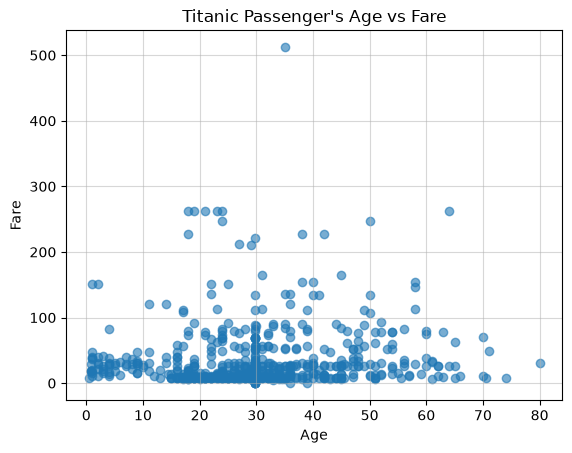

In [252]:
plt.scatter(X_train["Age"], X_train["Fare"], alpha=0.6)
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Titanic Passenger's Age vs Fare")
plt.grid(True, alpha=0.5)
plt.show()


Answer the following questions:
- What is the highest and lowest fare price? 

- What are the respective mean values of these two features? 

- What was the age of the oldest passenger?

In [253]:
print('Highest fare:', df_train['Fare'].max())
print('Lowest fare:', df_train['Fare'].min())
print('Mean age:', df_train['Age'].mean().round(2))
print('Mean fare:', df_train['Fare'].mean().round(2))
print('Age of oldest passenger:', df_train['Age'].max())



Highest fare: 512.3292
Lowest fare: 0.0
Mean age: 29.75
Mean fare: 32.53
Age of oldest passenger: 80.0


**Answers:**
- The highest fare price is approximately **512.33** and the lowest fare price is **0.00**
- The mean age is **29.75 years** and the mean fare is **32.53**
- The oldest passenger was of **80 years** old

2. Use the df_train dataframe. Using matplotlib visualize the number of males and females that survived and their respective passenger classes on two separate bar chart plots using `matplotlib.pyplot.bar` (Passenger Class column)

Survived males in class:
 Pclass
1    42
2    15
3    38
Name: count, dtype: int64
Survived females in class:
 Pclass
1    74
2    50
3    55
Name: count, dtype: int64


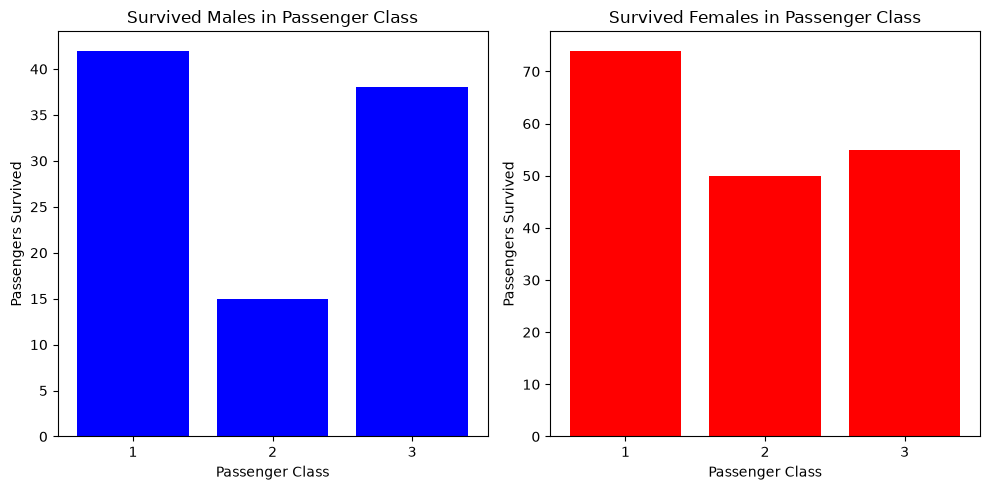

In [266]:
survived = df_train[df_train['Survived'] == 1]
male_counts = survived[survived['Sex'] == 'male']['Pclass'].value_counts().sort_index()
female_counts = survived[survived['Sex'] == 'female']['Pclass'].value_counts().sort_index()

print('Survived males in class:\n', male_counts)
print('Survived females in class:\n', female_counts)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].bar(male_counts.index.astype(str), male_counts.values, color='blue')
axes[0].set_xlabel('Passenger Class')
axes[0].set_ylabel('Passengers Survived')
axes[0].set_title('Survived Males in Passenger Class')

axes[1].bar(female_counts.index.astype(str), female_counts.values, color='red')
axes[1].set_xlabel('Passenger Class')
axes[1].set_ylabel('Passengers Survived')
axes[1].set_title('Survived Females in Passenger Class')

plt.tight_layout()
plt.show()

Answer the following questions:
- Which class of passengers had the least number of survived males and how many? Repeat this analysis for females.

- Which class of passengers had the greatest number of survived males and how many? Repeat this for females.

**Least Survived**: 

`Class 2` had the least survivor males`(15)` & 
`Class 2` had the least survivor females `(50)`



**Highest Survived**: 

`Class 1` had the highest survivor male `(42)` &
`Class 1` had the highest survivor female `(74)` 

3. Using the Target variable (Survived) in y_train plot a bar chart showing the distribution of the ‘Survived’ column. 

Survived
0    436
1    274
Name: count, dtype: int64


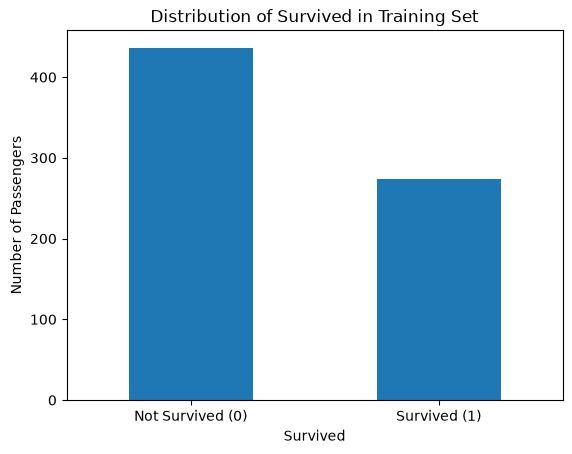

In [255]:
import matplotlib.pyplot as plt
import seaborn as sns

counts = y_train.value_counts().sort_index()

print(counts)

counts.plot(kind='bar')

plt.title('Distribution of Survived in Training Set')
plt.xlabel('Survived')
plt.ylabel('Number of Passengers')
plt.xticks(ticks=[0, 1], labels=['Not Survived (0)', 'Survived (1)'], rotation=0)

plt.show()

Answer the following question
- What initial comment can you make about this distribution in terms of the frequency of each class?

The dataset classes are moderately imbalanced:
* **Did not survive:** 436 passengers (**61.4%**)
* **Survived:** 274 passengers (**38.6%**)

There are roughly **1.6 times more non-survivors** than survivors. 


This matters because of this imbalance, **accuracy alone can be misleading**. A baseline model that blindly predicts "did not survive" for every passenger would automatically achieve a ~61% accuracy rate.

### Interpretation of the target distribution

Compare the two printed counts/proportions. The class with the larger frequency is the majority class. This is the appropriate initial comment on class balance for this training set.


4. So far you should have successfully been able to load, preprocess and visualize your data. Use the `pd.get_dummies()` function to convert categorical data into dummy variables (‘Sex’ and ‘Embarked’). Make sure to pass `drop_first=True` to the `get_dummies()` function. (Perform this only on X_train and store the result back into X_train). 

In [256]:
X_train = pd.get_dummies(X_train, columns=['Sex', 'Embarked'], drop_first=True, dtype=int)

print(X_train.shape)
print(X_train.head())

(710, 8)
   Pclass        Age  SibSp  Parch     Fare  Sex_male  Embarked_Q  Embarked_S
0       1  29.811847      0      0  30.5000         1           0           1
1       3  27.000000      0      2  11.1333         0           0           1
2       2  29.811847      0      0   0.0000         1           0           1
3       3   9.000000      4      2  31.2750         0           0           1
4       1  48.000000      1      0  39.6000         0           0           0


#### iii. Data Scaling

1. Use MinMaxScaler to scale only the **continuous attributes** of X_train. Apply the `fit_transform()` function of the scaler to obtain the scaled data and store it back in X_train.

In [257]:
scaler = MinMaxScaler()

continuous_columns = ['Age','Fare']
X_train[continuous_columns] = scaler.fit_transform(X_train[continuous_columns])

X_train.describe().loc[['min', 'max', 'mean', 'std']]

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,3.000000,1.000000,8.000000,6.000000,1.000000,1.000000,1.000000,1.000000
mean,2.287324,0.368623,0.561972,0.397183,0.063485,0.647887,0.081690,0.721127
std,0.845953,0.166791,1.140839,0.800207,0.090045,0.477966,0.274085,0.448761


2. Scale the X_test using the scaler you have just fit, this time using the `transform()` function. Note: Store the scaled values back into X_test. At the end of this step, you must have X_train, X_test, all scaled according to the MinMaxScaler.

In [258]:
X_test[continuous_columns] = scaler.transform(X_test[continuous_columns])

X_test.describe().loc[['min', 'max', 'mean', 'std']]

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
min,1.000000,0.003141,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,3.000000,0.886906,8.000000,5.000000,1.000000,1.000000,1.000000,1.000000
mean,2.407821,0.362113,0.374302,0.324022,0.059332,0.653631,0.106145,0.737430
std,0.783356,0.147135,0.929908,0.831969,0.120966,0.477147,0.308887,0.441265


### c. Modelling

#### i. Modelling (Model Instantiation / Training) using Logistic Regression classifier

1. Employ the Logistic Regression classifier from sklearn and instantiate the model. Label this model as ‘model_lr’  

In [259]:
lr_model = LogisticRegression()
lr_model

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

2. Once instantiated, `fit()` the model using the scaled X_train, y_train data.

In [260]:
lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

3. Employ the `predict()` function to obtain predictions on X_test and store this in a variable labeled as ‘y_pred_lr’.

In [261]:
y_pred_lr = lr_model.predict(X_test)
y_pred_lr

array([1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0,
       0, 0, 1])

4. Employ the `accuracy_score` function by using the ‘y_pred_lr’ and ‘y_test’ variables as the functions parameters and print the accuracy of the Logistic Regression model. 

In [262]:
lr_acc = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy: ", lr_acc)

Logistic Regression Accuracy:  0.8938547486033519


### d. Evaluation

#### i. Report F1 Score, Precision, Recall, Accuracy (All on the test set X_test, y_test)

1. Use `classification_report()` function from sklearn.metrics to report the precision, recall, and f1 score for each class for the `model_lr` model, along with a confusion matrix. 

In [263]:
print(classification_report(y_test, y_pred_lr))


              precision    recall  f1-score   support

           0       0.90      0.94      0.92       113
           1       0.89      0.82      0.85        66

    accuracy                           0.89       179
   macro avg       0.89      0.88      0.88       179
weighted avg       0.89      0.89      0.89       179



In [264]:
confusion_matrix = confusion_matrix(y_test, y_pred_lr)
print("Confusion Matrix:\n", confusion_matrix)

Confusion Matrix:
 [[106   7]
 [ 12  54]]


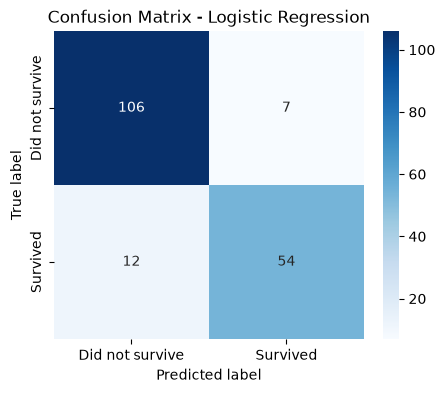

In [265]:
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Did not survive', 'Survived'],
            yticklabels=['Did not survive', 'Survived'])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()